In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
df = pd.read_csv('fraudTest.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [4]:
df.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

In [11]:
df.duplicated().any()

False

In [6]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [8]:
dummy_df = pd.get_dummies(df['gender'])
dummy_df.head()

,F,M
0,False,True
1,True,False
2,True,False
3,False,True
4,False,True


In [70]:
#normalization 
from sklearn.preprocessing import MinMaxScaler
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
print(df.head())


   Unnamed: 0  trans_date_trans_time    cc_num  merchant  category       amt  \
0    0.000000                      0  0.000459       319        10  0.000082   
1    0.000002                      1  0.000716       591        10  0.001267   
2    0.000004                      2  0.000721       611         5  0.001769   
3    0.000005                      3  0.000719       222         9  0.002594   
4    0.000007                      4  0.000706       292        13  0.000096   

   first  last  gender  street  ...  dob  trans_num     unix_time  merch_lat  \
0    151   115       1     341  ...  376      98699  0.000000e+00   0.313922   
1    163   457       0     354  ...  760     108785  4.785402e-07   0.428589   
2     24   249       0     865  ...  421     433979  1.674891e-06   0.450526   
3     42   457       1     320  ...  718      71993  2.990876e-06   0.205343   
4    247   261       1     548  ...  177     190585  3.110511e-06   0.544191   

   merch_long  is_fraud      F      M 

In [10]:
df.head()



,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


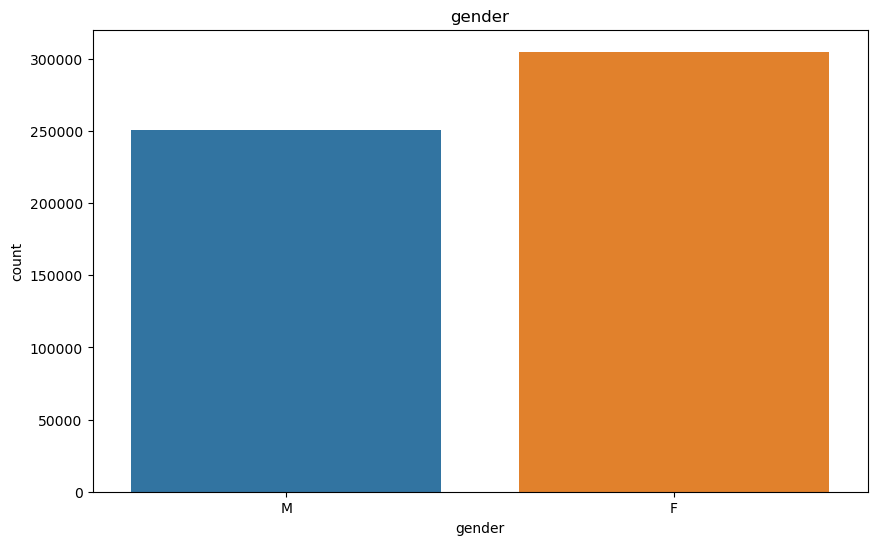

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=df)
plt.title('gender')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Display the first few rows of the dataset
df.head()

# Display the data types of each column
print(df.dtypes)

# Select object data type columns
object_columns = df.select_dtypes(include=['object']).columns

# Display the selected object columns
print(object_columns)

# Example visualization for the first object column
first_object_column = object_columns[0]

# Count occurrences of each unique value in the first object column
value_counts = df[first_object_column].value_counts()

# Plotting the value counts
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f'Value Counts of {first_object_column}')
plt.xlabel(first_object_column)
plt.ylabel('Count')
plt.show()


Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object
Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Display the first few rows of the dataset
df.head()

# Display the data types of each column
print(df.dtypes)

# Select object data type columns
object_columns = df.select_dtypes(include=['object']).columns

# Loop through each object column and plot the value counts
for column in object_columns:
    value_counts = df[column].value_counts()
    
    plt.figure(figsize=(10, 6))
    value_counts.plot(kind='bar')
    plt.title(f'Value Counts of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
# Count plot for categorical features
plt.figure(figsize=(10, 6))
sns.countplot(x='merchant', data=df)
plt.title('merchant Distribution')
plt.show()

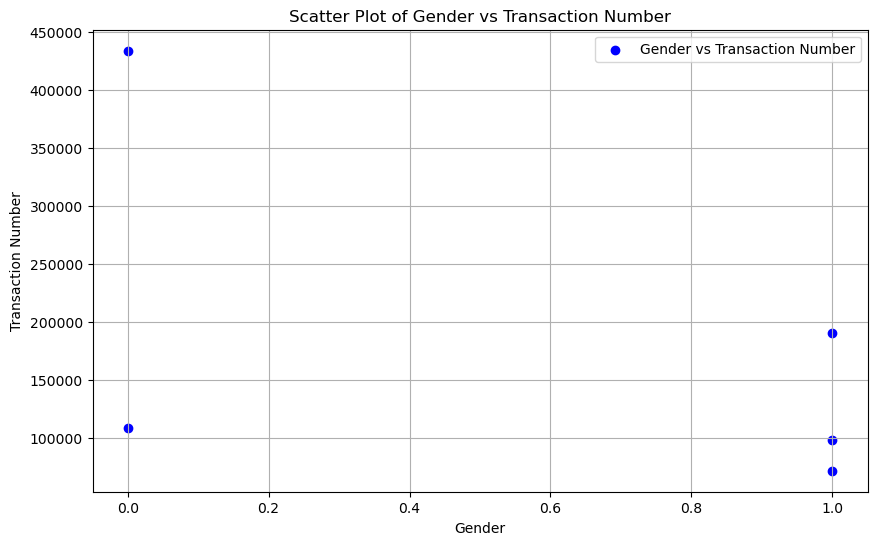

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(df['gender'], df['trans_num'], c='blue', label='Gender vs Transaction Number')
plt.title('Scatter Plot of Gender vs Transaction Number')
plt.xlabel('Gender')
plt.ylabel('Transaction Number')
plt.legend()
plt.grid(True)
plt.show()

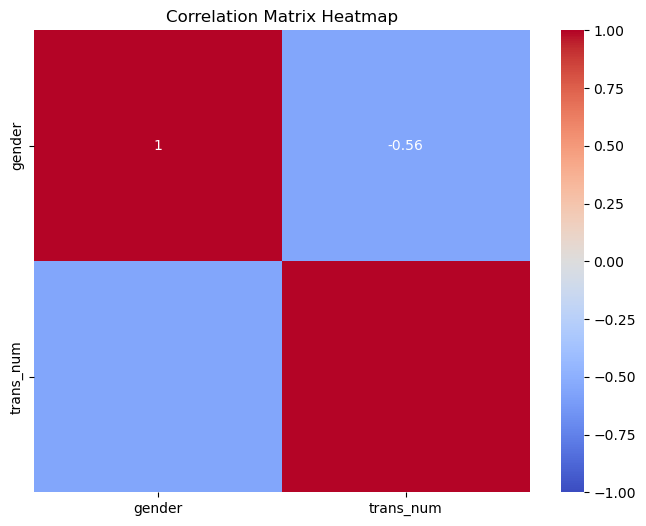

In [48]:
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [12]:
df["is_fraud"].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

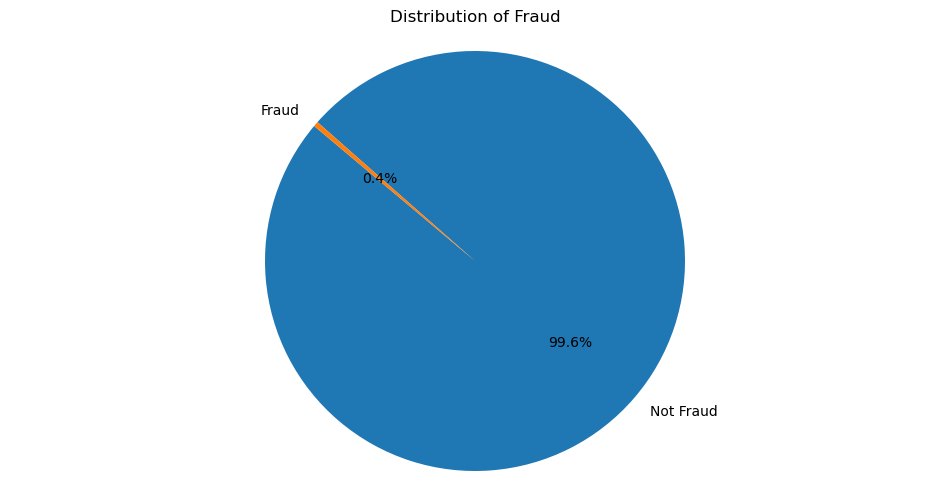

In [26]:
plt.figure(figsize = (12,6))
labels = ["Not Fraud","Fraud"]
values = df.is_fraud.value_counts()
plt.pie(values,labels = labels,autopct = "%1.1f%%",startangle = 140)
plt.title("Distribution of Fraud")
plt.axis("equal")
plt.show()

<Axes: xlabel='is_fraud'>

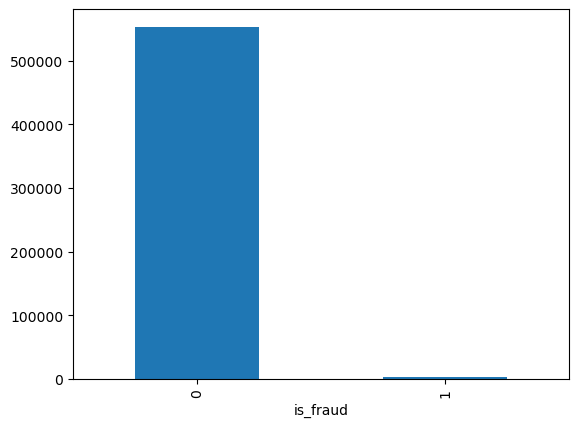

In [20]:
df.groupby("is_fraud").count()["cc_num"].plot(kind = "bar")

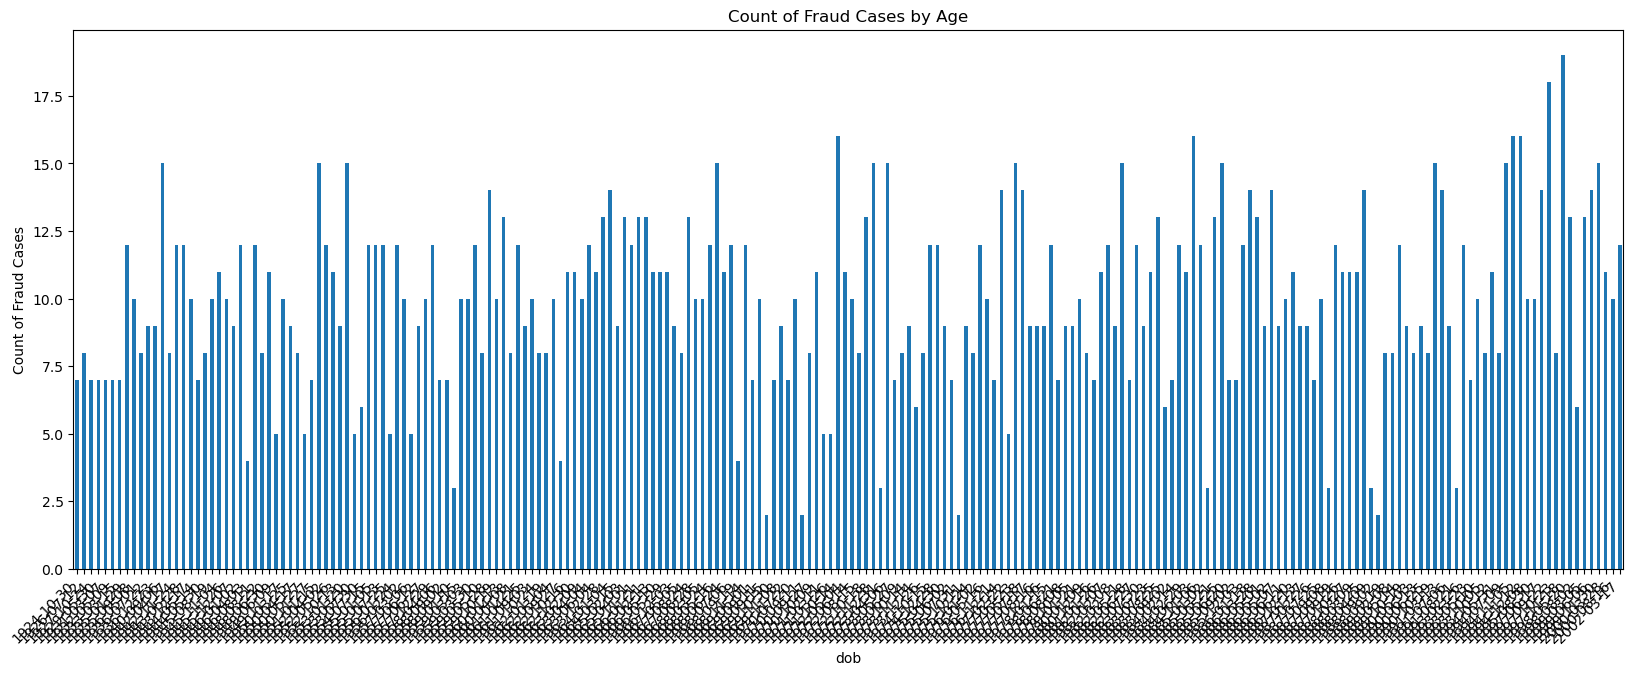

In [28]:
plt.figure(figsize=(20, 7))
ax = df[df['is_fraud'] == 1].groupby('dob').count()['is_fraud'].plot(kind='bar')
ax.set_xlabel('dob')
ax.set_ylabel('Count of Fraud Cases')
ax.set_title('Count of Fraud Cases by Age')
plt.xticks(rotation=45, ha='right')
plt.show()

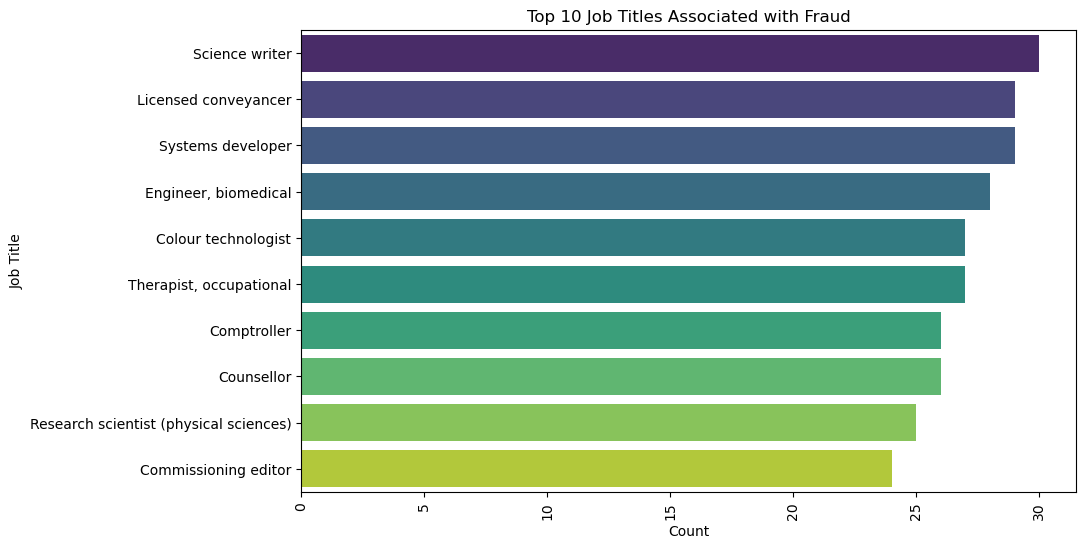

In [30]:
# Extract top 10 job titles associated with fraud and their counts
fraud_job_title = df[df["is_fraud"] == 1]["job"].value_counts().head(10)


# Convert to a DataFrame for easier plotting
fraud_job_title_df = fraud_job_title.reset_index()
fraud_job_title_df.columns = ['job', 'count']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=fraud_job_title_df, x="count", y="job",palette="viridis",dodge=False)
plt.title('Top 10 Job Titles Associated with Fraud')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.xticks(rotation=90)
plt.show()

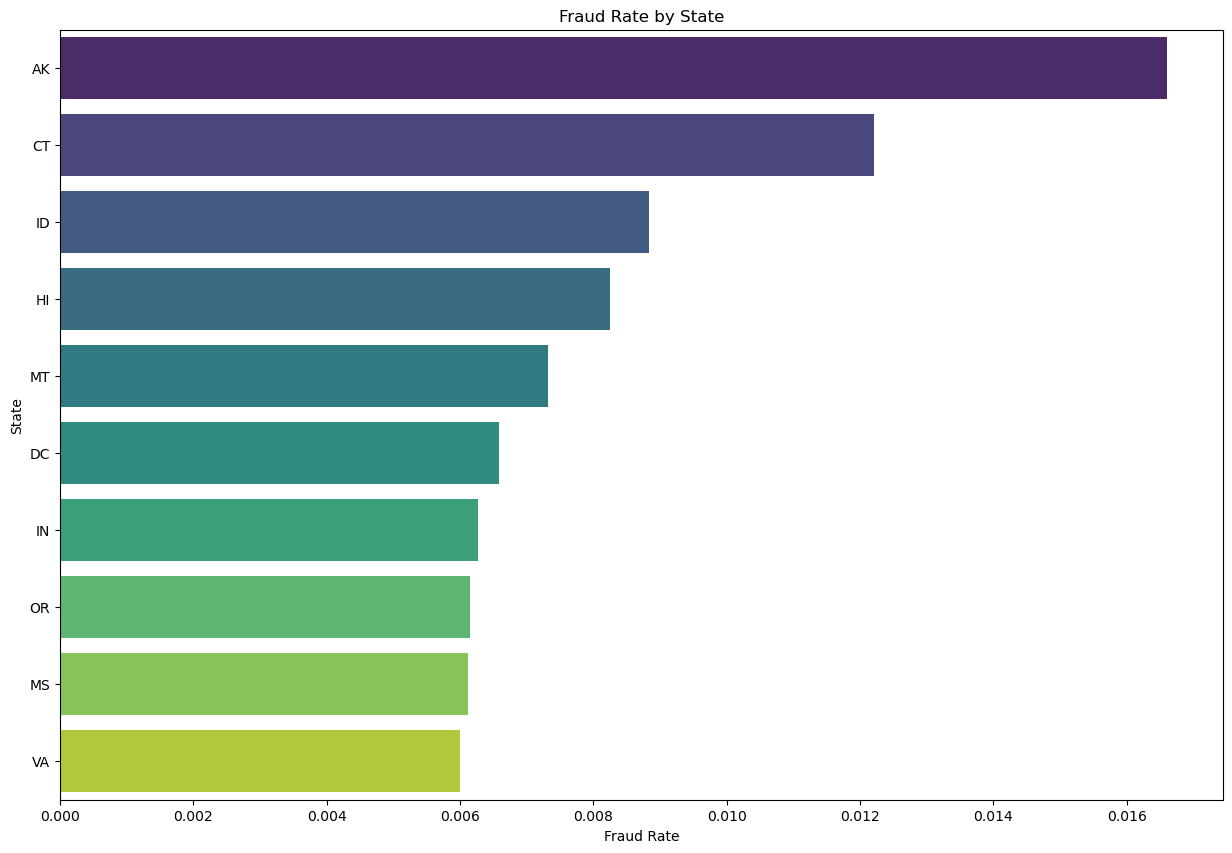

In [32]:
fraud_rate_by_state = df.groupby('state')['is_fraud'].mean().sort_values(ascending=False).reset_index().head(10)

plt.figure(figsize=(15, 10))
sns.barplot(data=fraud_rate_by_state, x='is_fraud', y='state', palette='viridis')
plt.title('Fraud Rate by State')
plt.xlabel('Fraud Rate')
plt.ylabel('State')
plt.show()

In [34]:
categorical_features = df.select_dtypes(include=['object']).columns
#Label Encoding
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Print the dataframe with label encoded columns
print(df.head())

   Unnamed: 0  trans_date_trans_time            cc_num  merchant  category  \
0           0                      0  2291163933867244       319        10   
1           1                      1  3573030041201292       591        10   
2           2                      2  3598215285024754       611         5   
3           3                      3  3591919803438423       222         9   
4           4                      4  3526826139003047       292        13   

     amt  first  last  gender  street  ...      lat      long  city_pop  job  \
0   2.86    151   115       1     341  ...  33.9659  -80.9355    333497  275   
1  29.84    163   457       0     354  ...  40.3207 -110.4360       302  392   
2  41.28     24   249       0     865  ...  40.6729  -73.5365     34496  259   
3  60.05     42   457       1     320  ...  28.5697  -80.8191     54767  407   
4   3.19    247   261       1     548  ...  44.2529  -85.0170      1126  196   

   dob  trans_num   unix_time  merch_lat  merch_lo

In [38]:
#categorial values convert into numerical values and drop the fruad 
columns = df.columns.tolist() 
columns.remove('is_fraud')

X = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']


scaler = StandardScaler()

X[columns] = scaler.fit_transform(X[columns])
df[X.columns] = X
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,-1.732048,-1.732669,-0.317252,-0.119663,0.961683,-0.424463,-0.232273,-0.994479,1.102494,-0.450296,...,-0.904377,0.677451,0.816521,0.243860,-0.461769,-1.116803,-1.703871,-0.894145,0.657586,0
1,-1.732041,-1.732663,-0.316273,1.231656,0.961683,-0.252337,-0.106449,1.568286,-0.907034,-0.401053,...,0.351182,-1.472454,-0.292685,1.102086,1.033750,-1.053931,-1.703869,0.178126,-1.436610,0
2,-1.732035,-1.732656,-0.316254,1.331017,-0.316151,-0.179353,-1.563901,0.009646,-0.907034,1.534597,...,0.420768,1.216667,-0.178853,0.126496,-0.286513,0.973182,-1.703865,0.383257,1.167640,0
3,-1.732029,-1.732650,-0.316259,-0.601568,0.706116,-0.059605,-1.375166,1.568286,1.102494,-0.529843,...,-1.970539,0.685934,-0.111371,1.212115,0.870177,-1.283276,-1.703861,-1.909485,0.680717,0
4,-1.732023,-1.732644,-0.316308,-0.253802,1.728384,-0.422358,0.774312,0.099567,1.102494,0.333812,...,1.128092,0.380004,-0.289942,-0.335625,-1.236791,-0.544027,-1.703861,1.259139,0.316510,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,1.732023,1.725931,-0.318978,0.814337,-0.316151,-0.163467,0.648489,0.504214,1.102494,0.269417,...,0.385244,-0.120967,-0.291963,1.600884,-0.625342,0.364862,1.510350,0.275527,-0.080241,0
555715,1.732029,1.725937,-0.316286,-0.392908,0.194983,0.270803,-0.022567,1.321002,1.102494,0.303509,...,-1.877757,-0.379599,-0.198018,-0.320955,1.540045,-1.293380,1.510351,-1.742946,-0.433644,0
555716,1.732035,1.725944,-0.314411,0.759688,0.194983,0.111564,-1.626812,-0.065289,-0.907034,-1.264708,...,1.512121,-2.089408,-0.281427,0.383230,0.445668,-0.266615,1.510352,1.592587,-2.146912,0
555717,1.732041,1.725950,-0.318998,-1.331876,1.728384,-0.391735,-0.651683,0.706538,1.102494,0.769428,...,1.201709,-1.910685,-0.293261,-1.347891,-0.637026,-1.460602,1.510354,1.163252,-1.955100,0


In [40]:
X.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long
0,-1.732048,-1.732669,-0.317252,-0.119663,0.961683,-0.424463,-0.232273,-0.994479,1.102494,-0.450296,...,-0.731091,-0.904377,0.677451,0.816521,0.243860,-0.461769,-1.116803,-1.703871,-0.894145,0.657586
1,-1.732041,-1.732663,-0.316273,1.231656,0.961683,-0.252337,-0.106449,1.568286,-0.907034,-0.401053,...,1.309217,0.351182,-1.472454,-0.292685,1.102086,1.033750,-1.053931,-1.703869,0.178126,-1.436610
2,-1.732035,-1.732656,-0.316254,1.331017,-0.316151,-0.179353,-1.563901,0.009646,-0.907034,1.534597,...,-1.382695,0.420768,1.216667,-0.178853,0.126496,-0.286513,0.973182,-1.703865,0.383257,1.167640
3,-1.732029,-1.732650,-0.316259,-0.601568,0.706116,-0.059605,-1.375166,1.568286,1.102494,-0.529843,...,-0.598119,-1.970539,0.685934,-0.111371,1.212115,0.870177,-1.283276,-1.703861,-1.909485,0.680717
4,-1.732023,-1.732644,-0.316308,-0.253802,1.728384,-0.422358,0.774312,0.099567,1.102494,0.333812,...,0.029394,1.128092,0.380004,-0.289942,-0.335625,-1.236791,-0.544027,-1.703861,1.259139,0.316510


In [42]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
# Assuming X is a DataFrame with datetime columns
# Remove datetime columns if they are not needed for modeling
#X = X.drop(columns=['dob'])  # Corrected syntax: drop(columns=['column_name'])

# Create RandomForestClassifier model
model_rfc = RandomForestClassifier(random_state=42, n_estimators=10, n_jobs=-1, max_depth=20)

# Fit the model
model_rfc.fit(X, y)

RandomForestClassifier(max_depth=20, n_estimators=10, n_jobs=-1,
                       random_state=42)

In [48]:
y_pred = model_rfc.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f'Accuracy Score: {accuracy}')

Accuracy Score: 0.9994601597927013
